In [1]:
import os
import numpy as np

import jax.random as random
import jax.numpy as jnp
from plots import plot_mdn_marginals
from mdn import MDN, get_cdf_vals
from mdn_inv import mdn_inv_marg
from data import mvn_posterior, sample_x_marginal
from utils import load_MDN, load_gen
from plots import plot_post_pairs
from gen import generator
from typing import List

In [2]:
key = random.PRNGKey(1)
path = "normal_exp/"

# load
dgp = np.load(os.path.join(path, "DGP.npz"))
L0 = jnp.array(dgp["L0"]) # (d, d)
L1 = jnp.array(dgp["L1"]) # (d, d)
prior_mean = jnp.array(dgp["prior_mean"]) # (d, 1)

d = L0.shape[0]

n_test = 4
key, t_key = random.split(key)
x_test = sample_x_marginal(t_key, n_test, prior_mean, L0, L1) # (n_test, d)

# true posterior

post_mean, post_var = mvn_posterior(x_test, prior_mean, L0, L1)


In [3]:
# get models
model_pars = np.load(os.path.join(path, "Pars.npz"))
mdn_hidden_dims=model_pars["mdn_hidden_dims"].tolist()             
gen_hidden_dims=model_pars["gen_hidden_dims"].tolist()
emb_dim=int(model_pars["emb_dim"])
K=int(model_pars["K"])

key, l1_key, l2_key, l3_key = random.split(key, 4)
y_par_list = [load_MDN(ckpt_dir=os.path.abspath(path + f"y_mdn/ckpt_{i}/"), model_def=MDN, rng_key=l1_key, hidden_dims=mdn_hidden_dims, K=K, x_dim=d)[1] for i in range(d)]
post_par_list = [load_MDN(ckpt_dir=os.path.abspath(path + f"post_mdn/ckpt_{i}/"), model_def=MDN, rng_key=l2_key, hidden_dims=mdn_hidden_dims, K=K, x_dim=d)[1] for i in range(d)]
gen_pars = load_gen(ckpt_dir=os.path.abspath(path + "gen/ckpt_gen/gen_0/"), model_def=generator, rng_key=l3_key, emb_dim=emb_dim, hidden_dims=gen_hidden_dims, out_dim=d, z_dim=d, x_dim=d)[1]
mdn = MDN(hidden_dims=mdn_hidden_dims, K=K)
gen = generator(emb_dim=emb_dim, hidden_dims=gen_hidden_dims, out_dim=d)



/Users/benriegler/miniconda3/envs/DL_jax/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1136: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


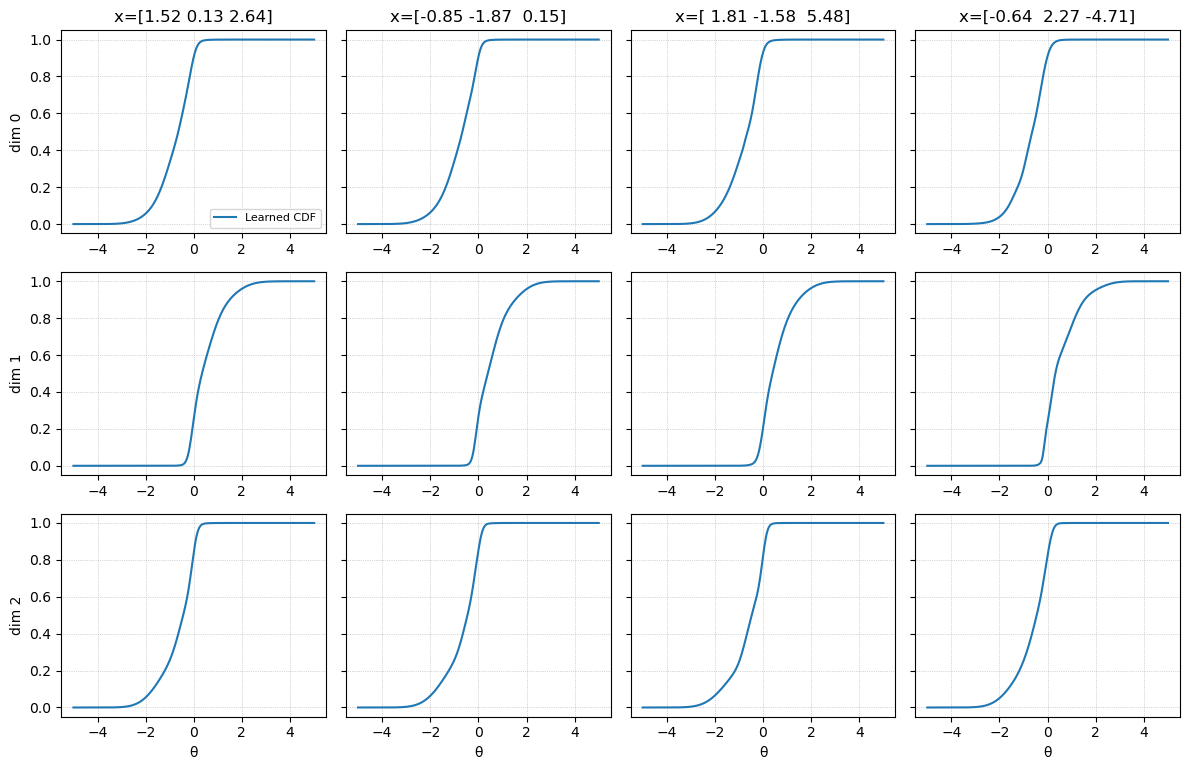

/Users/benriegler/Projects/IC-SBI/plots.py:559: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


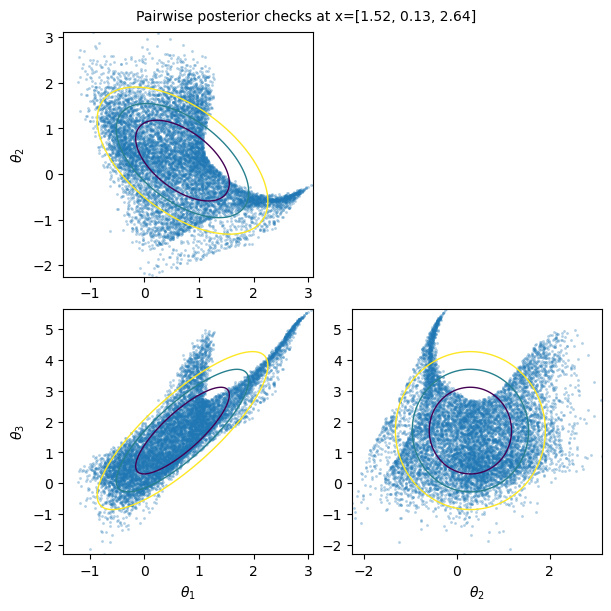

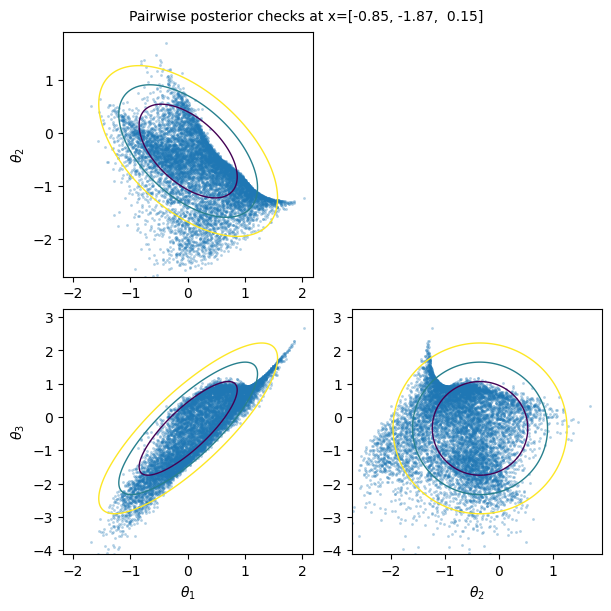

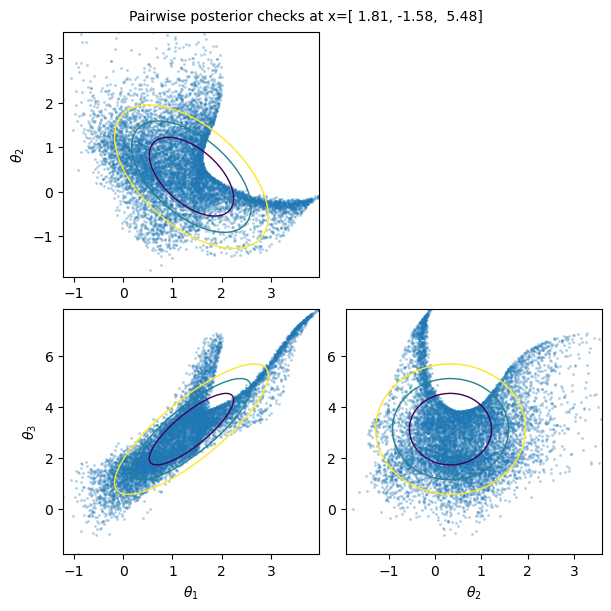

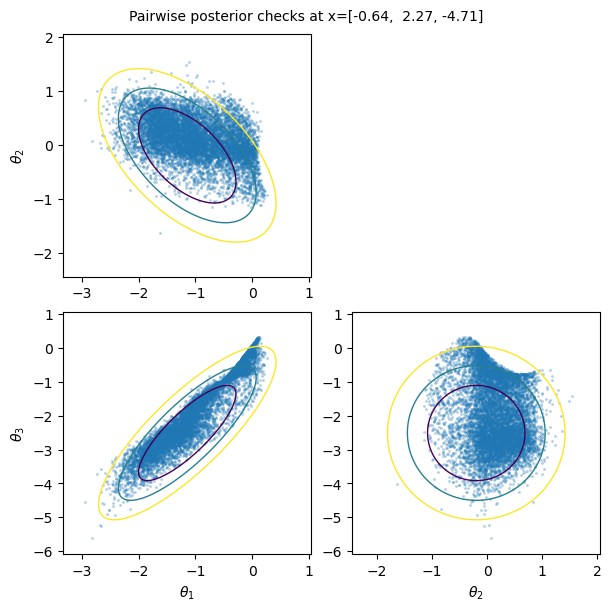

In [4]:
# test: posterior sampling
N_test = 10000

plot_mdn_marginals(model=mdn, params=y_par_list, x_vals=x_test, theta_range=(-5, 5))

key, z_key = random.split(key)

z_samples = random.normal(z_key, (n_test, N_test, d))
y_samples = gen.apply(gen_pars, z=z_samples, x=x_test[:, None, :]) # (test_locs, N_test, d) each test_loc gets its own N_test samples

# map into learned copula space
x_test_exp = jnp.repeat(x_test[:, None, :], axis=1, repeats=N_test)
v = get_cdf_vals(model=mdn, par_list=y_par_list, x_data=x_test_exp, θ_data=y_samples) # (test_locs, N_test, d)

# map into parameter space
theta = mdn_inv_marg(model = mdn, par_list=post_par_list, x=x_test_exp, u=v) # (test_locs, N_test, d)


# Ground-truth posterior params for just the test points
post_var = jnp.repeat(post_var[None, ...], axis=0, repeats=n_test)                   # (n_test, d, d)

# Make and save the figures
pairplot_dir = path + "pairplots/"
plot_post_pairs(
    theta=theta,                   # (test_locs, N_test, d)
    post_mean=post_mean,      # (test_locs, d) 
    post_cov=post_var,        # (test_locs, d, d)
    save_dir=None,
    x_vals=x_test,                 # optional, just for titles
    file_prefix="post_pairplot",
    max_scatter=None
)
